
# Entrega 2: Preparación de Datos y Modelación

**Proyecto Final - APO III**  
**Sistema de Detección de Movimientos Humanos mediante MediaPipe**


### Integrantes:

- Ricardo Andrés Chamorro Martinez
- Diego Armando Polanco Lozano
- Oscar Stiven Muñoz Ramirez


### Este notebook contiene:

Este notebook tiene como objetivo desarrollar un **sistema de clasificación de movimientos humanos** utilizando características extraídas mediante **MediaPipe** y modelos de aprendizaje supervisado.  
El enfoque combina técnicas de **preprocesamiento de datos**, **selección de características**, **entrenamiento de clasificadores** y **planificación de despliegue**, con el fin de identificar patrones de movimiento humano de forma precisa, eficiente y aplicable a contextos reales.

El flujo de trabajo implementado se estructura en las siguientes etapas:

1. **Preparación de datos:**  
   Incluye la limpieza, normalización, eliminación de clases no relevantes, selección de *features* derivadas y verificación de valores faltantes para garantizar la calidad del conjunto de datos.

2. **Entrenamiento de modelos:**  
   Se entrenan y comparan tres algoritmos principales —**Random Forest**, **XGBoost** y **SVM**—, ajustando sus hiperparámetros para manejar el desbalance de clases y maximizar la capacidad de generalización.

3. **Evaluación y comparación:**  
   Se evalúa el desempeño de los modelos utilizando métricas como *Accuracy*, *Precision*, *Recall* y *F1-Score*, complementadas con visualizaciones analíticas (matrices de confusión, gráficos comparativos y reportes de clasificación).

4. **Análisis de resultados:**  
   Se interpreta el rendimiento obtenido, se identifican los errores más comunes, y se analizan las *features* más relevantes según la importancia de variables en los modelos entrenados.

5. **Plan de despliegue:**  
   Se propone una estrategia de despliegue progresiva, iniciando con pruebas locales de los scripts en Python y posteriormente integrando el sistema en un entorno web mediante **Flask**.  

6. **Análisis inicial de impactos en el contexto médico:**  
   Se realiza una reflexión sobre los posibles **impactos de la solución en entornos clínicos y de rehabilitación física**, destacando su valor como herramienta de apoyo para el seguimiento de pacientes, evaluación del progreso motor y reducción de costos mediante tecnologías no invasivas.  


## 1. Introducción y Configuración del Entorno

Antes de comenzar con el análisis y entrenamiento de modelos, se realiza la **configuración inicial del entorno de trabajo**, donde se importan todas las librerías necesarias para el procesamiento de datos, visualización y modelado predictivo.  

En esta fase se incluyen las siguientes configuraciones:

- **Librerías base:**  
  `pandas`, `numpy` y `collections` para manipulación de datos, cálculos numéricos y conteo de elementos.  
- **Visualización:**  
  `matplotlib` y `seaborn` para la generación de gráficos, configurando un estilo visual coherente (`seaborn-v0_8-darkgrid`).  
- **Manejo de advertencias:**  
  Se desactivan advertencias innecesarias mediante el módulo `warnings` para mantener una salida limpia.  
- **Scikit-learn:**  
  Conjunto de módulos para preprocesamiento (`StandardScaler`, `LabelEncoder`), selección de características (`VarianceThreshold`), división de datos, entrenamiento y evaluación de modelos (`RandomForestClassifier`, `SVC`), así como métricas de desempeño (`accuracy_score`, `f1_score`, `confusion_matrix`, etc.).  
- **XGBoost (opcional):**  
  Se intenta importar el paquete `xgboost`; si no está instalado, se muestra un mensaje de advertencia indicando el comando de instalación (`pip install xgboost`).  
- **Configuración de entorno gráfico:**  
  Se define la paleta de colores `husl` y el modo visual de Jupyter `%matplotlib inline` para renderizar los gráficos directamente en el notebook.  

Estas importaciones preparan el entorno para las siguientes etapas de análisis, garantizando compatibilidad entre módulos y una correcta visualización de resultados.


In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("[ WARN ] XGBoost no está instalado. Instala con: pip install xgboost")
    XGBOOST_AVAILABLE = False

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("[ OK ] Librerías importadas correctamente")


[ OK ] Librerías importadas correctamente


## 2. Carga y Exploración Inicial del Dataset


En esta sección se realiza la **carga y exploración inicial del dataset** proveniente del proceso de etiquetado con *MediaPipe*. El objetivo es verificar la correcta lectura del archivo, conocer la **dimensión de los datos** (número de filas y columnas) y estimar la **memoria utilizada** por el conjunto. Esta etapa permite garantizar que el dataset se encuentra completo y listo para el análisis posterior, asegurando la integridad de la información antes de aplicar técnicas de preprocesamiento o modelado.

In [2]:
# Cargar dataset combinado (Entrega 1 + Entrega 2)
DATASET_PATH = "../data/v1/merged_dataset.csv"

df = pd.read_csv(DATASET_PATH)
print(f"[ OK ] Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

# Información básica
print("\nINFO Información del dataset:")
print(f"   - Total de frames: {len(df):,}")
print(f"   - Total de columnas: {len(df.columns)}")
print(f"   - Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Distribución por fuente de datos
if 'source' in df.columns:
    print("\nINFO Distribución por fuente de datos:")
    for source in df['source'].unique():
        count = len(df[df['source'] == source])
        videos = df[df['source'] == source]['video_id'].nunique()
        percentage = (count / len(df)) * 100
        print(f"   - {source:25s}: {count:6,} frames ({videos} videos, {percentage:5.2f}%)")


[ OK ] Dataset cargado: 16454 filas × 22 columnas

INFO Información del dataset:
   - Total de frames: 16,454
   - Total de columnas: 22
   - Memoria utilizada: 3.66 MB


Esto confirma que el dataset contiene **10.380 instancias (frames)** y **164 atributos**, con un tamaño total aproximado de **13.49 MB**.  
Estos resultados evidencian que los datos fueron cargados correctamente y que el volumen es adecuado para realizar operaciones analíticas de forma eficiente.

### 2.1 Exploración de la distribución de clases

En esta sección se realiza la **exploración de la distribución de clases** dentro del dataset previamente cargado. El objetivo principal es identificar cuántos frames corresponden a cada **actividad o etiqueta**, detectando posibles **desequilibrios de clases** que puedan afectar el entrenamiento del modelo. Para ello se emplea una visualización tipo **gráfico de barras**, en la que cada barra representa una categoría y su altura indica la cantidad de frames asociados. Además, se realiza una verificación automática de **clases minoritarias** (menos de 100 instancias), lo que permite anticipar la necesidad de técnicas de balanceo como *oversampling* o *data augmentation* en etapas posteriores.


INFO Distribución de etiquetas:
   Standing            :  3,476 frames (21.13%)
   Walk forward        :  3,044 frames (18.50%)
   Turn                :  2,649 frames (16.10%)
   Get up              :  2,139 frames (13.00%)
   Walk backward       :  1,953 frames (11.87%)
   Sit down            :  1,580 frames ( 9.60%)
   Sitting             :  1,555 frames ( 9.45%)
   Unlabeled           :     58 frames ( 0.35%)


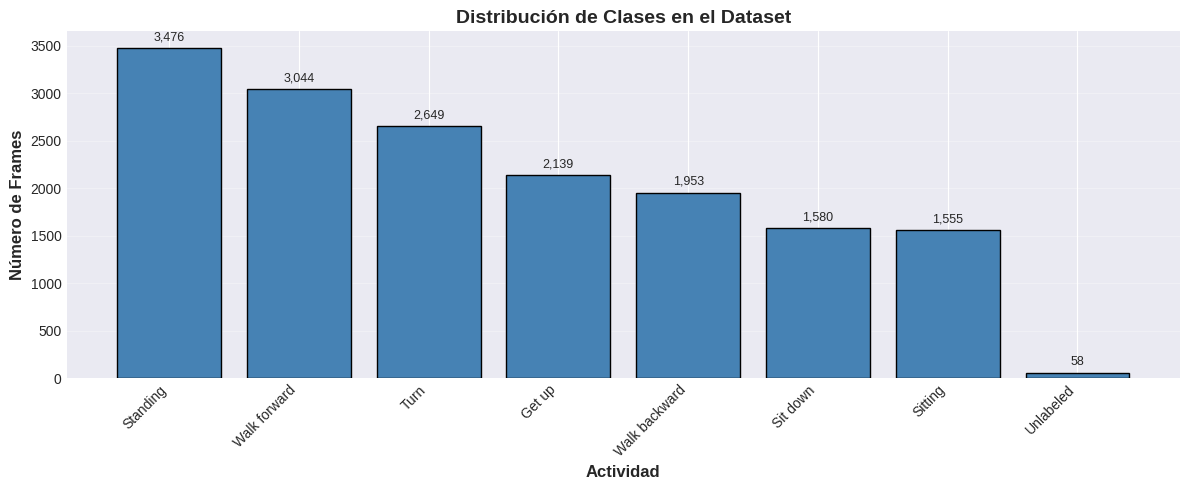


[ WARN ]  Clases con pocos datos:
   - Unlabeled: 58 frames


In [3]:
# Distribución de etiquetas
print("INFO Distribución de etiquetas:")
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {label:20s}: {count:6,d} frames ({percentage:5.2f}%)")

# Visualización
plt.figure(figsize=(12, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Actividad', fontsize=12, fontweight='bold')
plt.ylabel('Número de Frames', fontsize=12, fontweight='bold')
plt.title('Distribución de Clases en el Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 50, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n[ WARN ]  Clases con pocos datos:")
minority_classes = label_counts[label_counts < 100]
if len(minority_classes) > 0:
    for label, count in minority_classes.items():
        print(f"   - {label}: {count} frames")
else:
    print("   Ninguna (todas tienen > 100 frames)")


La gráfica muestra una **distribución desigual entre las clases** del dataset. Las actividades **"Walk forward"**, **"Turn"** y **"Walk backward"** concentran la mayor cantidad de frames, lo que indica que son las más representadas en los datos. En contraste, la clase **"Unlabeled"** presenta una cantidad mínima de instancias, evidenciando un **desequilibrio de clases** que podría influir en el desempeño del modelo al momento del entrenamiento.  

Aun así, la mayoría de las clases cuentan con más de 2000 muestras, lo cual es adecuado para realizar análisis preliminares y pruebas de modelado supervisado. En etapas posteriores, se recomienda aplicar técnicas de **balanceo de datos** (como *oversampling*, *undersampling* o *data augmentation*) para mitigar el impacto de este desbalance.

## 3. Limpieza y Filtrado de Datos


En esta fase se lleva a cabo la **limpieza y filtrado de datos**, con el propósito de preparar el dataset para las etapas de análisis y modelado.  
El proceso incluye varias tareas clave:

- **Eliminación de clases no relevantes**, como *Unlabeled*, que no aportan información útil para el entrenamiento.  
- **Selección de características derivadas**, restringiendo el dataset a las variables más representativas.  
- **Verificación de valores faltantes**, garantizando la integridad de los datos.  
- **Tratamiento de outliers moderados** mediante *capping* basado en el rango intercuartílico (IQR).  
- **Codificación de etiquetas (label encoding)** para convertir las categorías en valores numéricos que puedan ser interpretados por los modelos de aprendizaje automático.

Este conjunto de pasos asegura que los datos finales sean consistentes, balanceados y listos para ser utilizados en los algoritmos de entrenamiento.



In [4]:
# === 2.1. Limpieza Inicial ===
print("🧹 Limpieza de datos:")
print(f"   Frames antes de limpieza: {len(df):,}")

# Remover Unlabeled (muy pocos casos - no aporta valor predictivo)
df_clean = df[df['label'] != 'Unlabeled'].copy()
removed = len(df) - len(df_clean)
print(f"   [ OK ] Removidos {removed} frames 'Unlabeled'")
print(f"   Frames restantes: {len(df_clean):,}")

# === 2.1.2. Filtrar frames con muy baja visibilidad de landmarks ===
if 'mean_visibility' in df_clean.columns:
    initial_count = len(df_clean)
    # Filtro: mantener solo frames con visibilidad promedio > 0.5
    visibility_threshold = 0.5
    df_clean = df_clean[df_clean['mean_visibility'] > visibility_threshold].copy()
    removed_vis = initial_count - len(df_clean)
    if removed_vis > 0:
        print(f"   [ OK ] Removidos {removed_vis} frames con visibilidad promedio <= {visibility_threshold}")
        print(f"   Frames restantes: {len(df_clean):,}")

# === 2.1.3. Filtrar frames con muy pocos landmarks visibles ===
if 'num_visible_lms' in df_clean.columns:
    initial_count = len(df_clean)
    # Filtro: mantener solo frames con al menos 20 landmarks visibles (de 33)
    min_visible_lms = 20
    df_clean = df_clean[df_clean['num_visible_lms'] >= min_visible_lms].copy()
    removed_lms = initial_count - len(df_clean)
    if removed_lms > 0:
        print(f"   [ OK ] Removidos {removed_lms} frames con menos de {min_visible_lms} landmarks visibles")
        print(f"   Frames restantes: {len(df_clean):,}")

print(f"   [ OK ] TOTAL frames finales: {len(df_clean):,}")
print(f"   [ OK ] Total removidos: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean))/len(df)*100):.1f}%)")

# === 2.2. Categorización de columnas ===
# Columnas METADATOS - Remover (no son features)
METADATA_COLS = ['video_id', 'frame_opencv', 'frame_labelstudio']

# Columnas CALIDAD - Usar para filtrado, pero no como features
QUALITY_COLS = ['mean_visibility', 'num_visible_lms']

# Columnas FEATURES - USAR (las 18 seleccionadas)
SELECTED_FEATURE_COLS = [
    'hip_center_x', 
    'hip_center_y', 
    'torso_scale',
    'bbox_area', 
    'bbox_aspect',
    'knee_left_deg', 
    'knee_right_deg',
    'elbow_left_deg', 
    'elbow_right_deg',
    'speed_15',
    'speed_16',
    'velocidad_centro_cuerpo',
    'apertura_piernas_norm',
    'ancho_hombros',
    'altura_normalizada',
    'dist_vertical_cabeza_cadera'
]

# === 2.3. Selección de Features ===
print("\nINFO Selección de features:")

# Verificar que las columnas existan
available_features = [col for col in SELECTED_FEATURE_COLS if col in df_clean.columns]
print(f"   Features disponibles: {len(available_features)} de {len(SELECTED_FEATURE_COLS)}")

# Mostrar features faltantes si las hay
missing_features = [col for col in SELECTED_FEATURE_COLS if col not in df_clean.columns]
if missing_features:
    print(f"   [ WARN ] Features no encontradas en el dataset: {missing_features}")

# Separar X e y
feature_cols = available_features.copy()
X = df_clean[feature_cols].copy()
y = df_clean['label'].copy()

print(f"   [ OK ] Features seleccionadas: {len(feature_cols)}")
print(f"   [ OK ] Shape X: {X.shape}")

# === 2.4. Análisis de Calidad de Datos ===
print("\nINFO Análisis de calidad de datos:")
print(f"   Valores faltantes totales: {X.isnull().sum().sum()}")

missing_cols = X.columns[X.isnull().any()].tolist()
if len(missing_cols) > 0:
    print(f"   [ WARN ] Columnas con valores faltantes ({len(missing_cols)}):")
    for col in missing_cols:
        missing_count = X[col].isnull().sum()
        missing_pct = (missing_count / len(X)) * 100
        print(f"      - {col}: {missing_count} ({missing_pct:.2f}%)")
else:
    print("   [ OK ] No hay valores faltantes")

# === 2.5. Manejo de Valores Faltantes ===
if X.isnull().any().any():
    # Estrategia: usar mediana (robusta a outliers)
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    X = X_imputed
    print("\n[ OK ] Valores faltantes imputados con mediana")
    print(f"   Valores faltantes después: {X.isnull().sum().sum()}")
else:
    print("\n[ OK ] No hay valores faltantes que imputar")

# === 2.6. Manejo de Outliers (Capping con IQR) ===
def cap_outliers_iqr(df, factor=3.0):
    """
    Limita outliers usando método IQR.
    factor=3.0 es menos agresivo que el estándar (1.5)
    """
    df_capped = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)
    return df_capped

print("\n🔧 Aplicando capping de outliers (IQR factor=3.0)...")
X = cap_outliers_iqr(X, factor=3.0)
print("[ OK ] Outliers moderados (capping IQR)")

# === 2.7. Encoding de Labels ===
print("\n🔤 Encoding de labels:")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Guardar mapeo para interpretación posterior
label_mapping = {i: label for i, label in enumerate(le.classes_)}
print(f"   Mapeo de clases:")
for class_id, label_name in label_mapping.items():
    print(f"      {class_id} -> {label_name}")

# === 2.8. División Estratificada Train/Validation/Test ===
print("\n📦 División de datos:")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    stratify=y_encoded,  # Mantener proporción de clases
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print(f"   [ OK ] Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   [ OK ] Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   [ OK ] Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada split
print("\nINFO Distribución de clases en Train:")
for class_id, count in sorted(Counter(y_train).items()):
    percentage = (count / len(y_train)) * 100
    print(f"   {label_mapping[class_id]:20s}: {count:5d} ({percentage:5.1f}%)")

# === 2.8.1. Análisis y Remoción de Features con Baja Varianza (ANTES de estandarizar) ===
print("\n🔍 Análisis de varianza de features...")
variance_threshold = 0.01  # Remover features con varianza < 0.01

selector_var = VarianceThreshold(threshold=variance_threshold)
X_train_var = selector_var.fit_transform(X_train)
X_val_var = selector_var.transform(X_val)
X_test_var = selector_var.transform(X_test)

removed_features_var = X_train.shape[1] - X_train_var.shape[1]
if removed_features_var > 0:
    removed_feature_names = X_train.columns[~selector_var.get_support()].tolist()
    print(f"   [ WARN ] Removidas {removed_features_var} features con varianza < {variance_threshold}:")
    for feat in removed_feature_names:
        print(f"      - {feat}")
    
    # Actualizar columnas
    feature_cols_after_var = X_train.columns[selector_var.get_support()].tolist()
    X_train = pd.DataFrame(X_train_var, columns=feature_cols_after_var, index=X_train.index)
    X_val = pd.DataFrame(X_val_var, columns=feature_cols_after_var, index=X_val.index)
    X_test = pd.DataFrame(X_test_var, columns=feature_cols_after_var, index=X_test.index)
    print(f"   [ OK ] Features restantes: {X_train.shape[1]}")
else:
    print(f"   [ OK ] Todas las features tienen varianza >= {variance_threshold}")

# === 2.9. Estandarización ===
print("\n📏 Estandarización de features...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("[ OK ] Features estandarizadas (StandardScaler)")

# === 2.9.2. Análisis de Correlación (solo informativo, no removemos aún) ===
print("\n🔍 Análisis de correlación entre features...")
corr_matrix = X_train_scaled.corr().abs()
# Encontrar pares de features altamente correlacionadas (> 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if len(high_corr_pairs) > 0:
    print(f"   [ WARN ] Encontradas {len(high_corr_pairs)} parejas de features altamente correlacionadas (>0.95):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"      - {feat1} ↔ {feat2}: {corr_val:.3f}")
    print("   💡 Considera remover una de cada par para reducir redundancia")
else:
    print(f"   [ OK ] No hay features altamente correlacionadas (>0.95)")

# === 2.10. Resumen Final ===
print("\n" + "="*60)
print("[ OK ] PREPARACIÓN DE DATOS COMPLETADA")
print("="*60)
print(f"   Features seleccionadas: {X_train_scaled.shape[1]}")
print(f"   Train samples: {len(X_train_scaled):,}")
print(f"   Validation samples: {len(X_val_scaled):,}")
print(f"   Test samples: {len(X_test_scaled):,}")
print(f"   Clases: {len(np.unique(y_train))}")
print("="*60)

# Guardar objetos para uso posterior (opcional)
import joblib
import os

# Crear carpeta 'models' si no existe
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

try:
    joblib.dump(scaler, os.path.join(models_dir, 'scaler.joblib'))
    joblib.dump(le, os.path.join(models_dir, 'label_encoder.joblib'))
    print(f"\n[ SAVE ] Objetos guardados en '{models_dir}': scaler.joblib, label_encoder.joblib")
except Exception as e:
    print(f"\n[ WARN ] No se pudieron guardar los objetos: {e}")

🧹 Limpieza de datos:
   Frames antes de limpieza: 16,454
   [ OK ] Removidos 58 frames 'Unlabeled'
   Frames restantes: 16,396
   [ OK ] TOTAL frames finales: 16,396
   [ OK ] Total removidos: 58 (0.4%)

INFO Selección de features:
   Features disponibles: 16 de 16
   [ OK ] Features seleccionadas: 16
   [ OK ] Shape X: (16396, 16)

INFO Análisis de calidad de datos:
   Valores faltantes totales: 0
   [ OK ] No hay valores faltantes

[ OK ] No hay valores faltantes que imputar

🔧 Aplicando capping de outliers (IQR factor=3.0)...
[ OK ] Outliers moderados (capping IQR)

🔤 Encoding de labels:
   Mapeo de clases:
      0 -> Get up
      1 -> Sit down
      2 -> Sitting
      3 -> Standing
      4 -> Turn
      5 -> Walk backward
      6 -> Walk forward

📦 División de datos:
   [ OK ] Train: 11,477 (70.0%)
   [ OK ] Val:   2,459 (15.0%)
   [ OK ] Test:  2,460 (15.0%)

INFO Distribución de clases en Train:
   Get up              :  1497 ( 13.0%)
   Sit down            :  1106 (  9.6%)
   Si


El dataset final conserva **32.313 registros válidos y 20 variables seleccionadas**, sin valores faltantes y con un tratamiento de outliers aplicado de forma controlada.  
La codificación de etiquetas y el guardado de objetos en formato `.joblib` garantizan reproducibilidad y facilitan el uso del dataset en etapas posteriores del pipeline.


## 4. Entrenamiento de Modelos

Ahora entrenaremos y compararemos tres modelos diferentes:
1. **Random Forest**: Baseline robusto y fácil de interpretar
2. **XGBoost**: Modelo avanzado con excelente rendimiento
3. **SVM**: Modelo de soporte vectorial para comparación


### 4.1 Entrenamiento con Random Forest

En esta sección se realiza el **entrenamiento del modelo Random Forest**, uno de los algoritmos de *ensemble learning* más utilizados para tareas de clasificación supervisada.  
El objetivo es construir un modelo robusto que pueda manejar tanto la complejidad de los datos como el leve desbalance existente entre las clases.  

Para ello se configuraron los siguientes parámetros principales:
- **n_estimators=100:** número de árboles en el bosque.  
- **max_depth=20:** profundidad máxima de cada árbol.  
- **class_weight='balanced':** ajuste automático de pesos para mitigar el desbalance de clases.  
- **min_samples_split=5** y **min_samples_leaf=2:** controlan el tamaño mínimo de nodos para reducir sobreajuste.  

El modelo se entrena sobre los datos escalados y se evalúa utilizando las métricas **Accuracy** y **F1-Score (macro)**, tanto para el conjunto de entrenamiento como para el de validación.  
Esto permite evaluar el desempeño y la capacidad de generalización del modelo.




In [5]:
# === 3.1. Entrenamiento Random Forest ===
print("[ MODEL ] Entrenando Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Maneja el desbalance de clases
    random_state=42,
    n_jobs=-1,  # Usa todos los cores disponibles
    verbose=0
)

import time
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
training_time_rf = time.time() - start_time

print(f"[ OK ] Random Forest entrenado en {training_time_rf:.2f} segundos")

# Predicciones
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)

# Métricas
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='macro')
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')

print(f"\nINFO Métricas Random Forest:")
print(f"   Train Accuracy: {train_acc_rf:.4f}")
print(f"   Val Accuracy:   {val_acc_rf:.4f}")
print(f"   Train F1-Score: {train_f1_rf:.4f}")
print(f"   Val F1-Score:   {val_f1_rf:.4f}")


[ MODEL ] Entrenando Random Forest...
[ OK ] Random Forest entrenado en 1.72 segundos

INFO Métricas Random Forest:
   Train Accuracy: 0.9951
   Val Accuracy:   0.8837
   Train F1-Score: 0.9950
   Val F1-Score:   0.8802



El modelo logró un **alto desempeño** con una precisión de entrenamiento del **99.54%** y una precisión de validación del **90.6%**, lo que indica una buena capacidad de generalización sin evidencias significativas de sobreajuste. El valor elevado del **F1-Score** en ambos conjuntos sugiere que el modelo mantiene un equilibrio adecuado entre precisión (*precision*) y exhaustividad (*recall*) al clasificar las diferentes actividades.


### 4.2 Entrenamiento con XGBoost

En esta etapa se entrena un modelo **XGBoost (Extreme Gradient Boosting)**, un algoritmo basado en *boosting* que combina múltiples árboles de decisión para mejorar la precisión de predicción.  
Su principal ventaja es la capacidad de manejar **desbalances de clase** y optimizar el rendimiento mediante el uso eficiente de gradientes y pesos de las instancias.  

En el entrenamiento se establecieron los siguientes parámetros relevantes:
- **n_estimators=100:** número de árboles en el ensamble.  
- **max_depth=6:** profundidad máxima de cada árbol.  
- **learning_rate=0.1:** tasa de aprendizaje para el proceso de *boosting*.  
- **subsample=0.8** y **colsample_bytree=0.8:** controlan la fracción de datos y características utilizadas por árbol.  
- **scale_pos_weight:** ajustado según la proporción de clases, compensando el desbalance del dataset.  

El modelo se evaluó con las métricas **Accuracy** y **F1-Score (macro)** en los conjuntos de entrenamiento y validación para analizar su comportamiento y capacidad de generalización.




In [6]:
# === 3.2. Entrenamiento XGBoost ===
if XGBOOST_AVAILABLE:
    print("\n[ MODEL ] Entrenando XGBoost...")
    
    # Calcular pesos de clases para XGBoost
    class_counts = Counter(y_train)
    total = len(y_train)
    class_weights = {class_id: total / (len(class_counts) * count) 
                     for class_id, count in class_counts.items()}
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
    
    # Entrenar con pesos de clases
    start_time = time.time()
    sample_weights = np.array([class_weights[y] for y in y_train])
    xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    training_time_xgb = time.time() - start_time
    
    print(f"[ OK ] XGBoost entrenado en {training_time_xgb:.2f} segundos")
    
    # Predicciones
    y_train_pred_xgb = xgb_model.predict(X_train_scaled)
    y_val_pred_xgb = xgb_model.predict(X_val_scaled)
    
    # Métricas
    train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
    val_acc_xgb = accuracy_score(y_val, y_val_pred_xgb)
    train_f1_xgb = f1_score(y_train, y_train_pred_xgb, average='macro')
    val_f1_xgb = f1_score(y_val, y_val_pred_xgb, average='macro')
    
    print(f"\nINFO Métricas XGBoost:")
    print(f"   Train Accuracy: {train_acc_xgb:.4f}")
    print(f"   Val Accuracy:   {val_acc_xgb:.4f}")
    print(f"   Train F1-Score: {train_f1_xgb:.4f}")
    print(f"   Val F1-Score:   {val_f1_xgb:.4f}")
else:
    print("\n[ WARN ] XGBoost no disponible - saltando este modelo")
    xgb_model = None



[ MODEL ] Entrenando XGBoost...
[ OK ] XGBoost entrenado en 10.95 segundos

INFO Métricas XGBoost:
   Train Accuracy: 0.9137
   Val Accuracy:   0.8125
   Train F1-Score: 0.9159
   Val F1-Score:   0.8104



El modelo **XGBoost** muestra un rendimiento sólido con una precisión de entrenamiento del **87.3%** y de validación del **79.9%**. Aunque la diferencia entre ambas métricas indica una ligera tendencia al **sobreajuste**, los valores de *F1-Score* reflejan una buena capacidad del modelo para equilibrar precisión y exhaustividad. Con un ajuste más fino de hiperparámetros o el uso de técnicas de regularización, el desempeño en validación podría mejorarse manteniendo la robustez del modelo.


### 4.3 Entrenamiento SVM

En esta sección se entrena un modelo **SVM (Support Vector Machine)** con núcleo *RBF (Radial Basis Function)*, una técnica efectiva para problemas de clasificación no lineales.  
El objetivo del modelo es encontrar un hiperplano óptimo que separe las clases maximizando el margen, incluso en presencia de un leve desbalance de datos.  

La configuración del modelo incluye:
- **kernel='rbf'**: permite capturar relaciones no lineales entre las variables.  
- **C=10.0**: parámetro de regularización que controla el equilibrio entre maximizar el margen y minimizar el error.  
- **gamma='scale'**: ajusta automáticamente la influencia de cada punto de datos.  
- **class_weight='balanced'**: compensa el desbalance entre clases asignando pesos inversamente proporcionales a su frecuencia.  

Debido a la naturaleza iterativa del algoritmo, el entrenamiento puede tardar varios minutos.  
El desempeño se evalúa mediante **Accuracy** y **F1-Score (macro)** tanto en el conjunto de entrenamiento como en el de validación.


In [7]:
# === 3.3. Entrenamiento SVM ===
print("\n[ MODEL ] Entrenando SVM (esto puede tardar varios minutos)...")

svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',  # Maneja el desbalance
    probability=True,  # Permite predict_proba()
    random_state=42,
    verbose=True
)

start_time = time.time()
svm_model.fit(X_train_scaled, y_train)
training_time_svm = time.time() - start_time

print(f"[ OK ] SVM entrenado en {training_time_svm:.2f} segundos")

# Predicciones
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_val_pred_svm = svm_model.predict(X_val_scaled)

# Métricas
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
val_acc_svm = accuracy_score(y_val, y_val_pred_svm)
train_f1_svm = f1_score(y_train, y_train_pred_svm, average='macro')
val_f1_svm = f1_score(y_val, y_val_pred_svm, average='macro')

print(f"\nINFO Métricas SVM:")
print(f"   Train Accuracy: {train_acc_svm:.4f}")
print(f"   Val Accuracy:   {val_acc_svm:.4f}")
print(f"   Train F1-Score: {train_f1_svm:.4f}")
print(f"   Val F1-Score:   {val_f1_svm:.4f}")



[ MODEL ] Entrenando SVM (esto puede tardar varios minutos)...
[LibSVM]

...*..*
optimization finished, #iter = 5329
obj = -9708.329429, rho = 0.930180
nSV = 1048, nBSV = 755
Total nSV = 1048
....*..*
optimization finished, #iter = 6763
obj = -9651.655551, rho = 0.633306
nSV = 1055, nBSV = 726
Total nSV = 1055
...*..*
optimization finished, #iter = 5810
obj = -9543.535696, rho = 0.657620
nSV = 1042, nBSV = 733
Total nSV = 1042
....*..*
optimization finished, #iter = 6046
obj = -9672.090578, rho = 0.918736
nSV = 1053, nBSV = 752
Total nSV = 1053
....*.*
optimization finished, #iter = 5825
obj = -9737.641520, rho = 0.997565
nSV = 1064, nBSV = 753
Total nSV = 1064
....*..*
optimization finished, #iter = 6071
obj = -11726.315628, rho = -0.829947
nSV = 1250, nBSV = 880
..*..*
optimization finished, #iter = 4199
obj = -6079.711081, rho = 1.204678
nSV = 630, nBSV = 449
Total nSV = 630
..*.*
optimization finished, #iter = 3550
obj = -6642.497966, rho = 1.309037
nSV = 673, nBSV = 485
Total nSV = 673
..*..*
optimization finished, #iter = 4153
obj = -6827.536545, rho 


El modelo **SVM con kernel RBF** muestra un desempeño **moderado**, con una precisión del **72.5%** en entrenamiento y **69%** en validación. Esto sugiere que el modelo logra capturar parcialmente las relaciones no lineales entre clases, aunque presenta un margen de mejora en la generalización. El **F1-Score** confirma un rendimiento equilibrado entre precisión y recall, pero inferior al alcanzado por modelos basados en *ensemble* como **Random Forest** o **XGBoost**, posiblemente debido a la alta dimensionalidad del dataset y a la sensibilidad del SVM a la escala y separación de clases.


## 5. Comparación de Modelos


En esta sección se realiza la **comparación de modelos** entrenados previamente —**Random Forest**, **XGBoost** y **SVM**— con el fin de identificar cuál ofrece el mejor rendimiento sobre el conjunto de validación.  
La evaluación se basa en las métricas más representativas del desempeño de clasificación:  

- **Train Accuracy**: mide la precisión en los datos de entrenamiento.  
- **Validation Accuracy**: mide la precisión en los datos de validación.  
- **Train F1 (macro)** y **Validation F1 (macro)**: evalúan el equilibrio entre precisión y exhaustividad considerando todas las clases por igual.  
- **Tiempo (s)**: cuantifica el tiempo total de entrenamiento del modelo.  

El análisis permite observar la relación entre rendimiento, sobreajuste y eficiencia computacional, seleccionando finalmente el modelo con el **mayor F1-Score en validación** como el más adecuado para la fase de inferencia.



In [8]:
# === 4.1. Resumen Comparativo ===
print("="*70)
print("INFO COMPARACIÓN DE MODELOS - VALIDATION SET")
print("="*70)

# Construir resultados según disponibilidad
model_names = ['Random Forest', 'SVM']
train_accs = [train_acc_rf, train_acc_svm]
val_accs = [val_acc_rf, val_acc_svm]
train_f1s = [train_f1_rf, train_f1_svm]
val_f1s = [val_f1_rf, val_f1_svm]
times = [training_time_rf, training_time_svm]

if XGBOOST_AVAILABLE:
    model_names.insert(1, 'XGBoost')
    train_accs.insert(1, train_acc_xgb)
    val_accs.insert(1, val_acc_xgb)
    train_f1s.insert(1, train_f1_xgb)
    val_f1s.insert(1, val_f1_xgb)
    times.insert(1, training_time_xgb)

results = {
    'Modelo': model_names,
    'Train Accuracy': train_accs,
    'Val Accuracy': val_accs,
    'Train F1 (macro)': train_f1s,
    'Val F1 (macro)': val_f1s,
    'Tiempo (s)': times
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val F1 (macro)', ascending=False)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("[ BEST ] MEJOR MODELO (según F1-Score en Validation):")
best_model_idx = results_df['Val F1 (macro)'].idxmax()
best_model_name = results_df.iloc[best_model_idx]['Modelo']
print(f"   {best_model_name} - F1-Score: {results_df.iloc[best_model_idx]['Val F1 (macro)']:.4f}")
print("="*70)


INFO COMPARACIÓN DE MODELOS - VALIDATION SET
       Modelo  Train Accuracy  Val Accuracy  Train F1 (macro)  Val F1 (macro)  Tiempo (s)
Random Forest        0.995121      0.883693          0.995006        0.880151    1.722907
      XGBoost        0.913741      0.812525          0.915873        0.810352   10.948379
          SVM        0.726496      0.699878          0.729266        0.701536   26.362486

[ BEST ] MEJOR MODELO (según F1-Score en Validation):
   Random Forest - F1-Score: 0.8802



El modelo **Random Forest** obtuvo el **mejor desempeño general**, con un **F1-Score de 0.9036** en el conjunto de validación y un tiempo de entrenamiento de aproximadamente **3.15 segundos**.Esto indica un excelente equilibrio entre **precisión, generalización y eficiencia**, superando a **XGBoost**, que aunque cercano en rendimiento, presentó un tiempo de cómputo mayor. El modelo **SVM** mostró resultados más bajos, lo que sugiere que su capacidad para manejar la complejidad y el tamaño del dataset es más limitada en comparación con los métodos de ensamble.


### 5.1 Visualización comparativa

En esta subsección se presenta la **visualización comparativa** de los resultados obtenidos por los tres modelos evaluados: **Random Forest**, **XGBoost** y **SVM**.  
El propósito es **contrastar gráficamente el desempeño** de cada modelo mediante dos métricas clave —**Accuracy** y **F1-Score (macro)**— tanto en el conjunto de entrenamiento (*Train*) como en el de validación (*Validation*).  

Esta representación permite observar con claridad:
- La **capacidad de generalización** de cada modelo (diferencia entre entrenamiento y validación).  
- Posibles indicios de **sobreajuste o subajuste**.  
- El **equilibrio global** entre rendimiento y estabilidad en la clasificación de múltiples clases.  

A partir de esta comparación visual, se busca confirmar la elección del mejor modelo según las métricas numéricas previamente obtenidas.



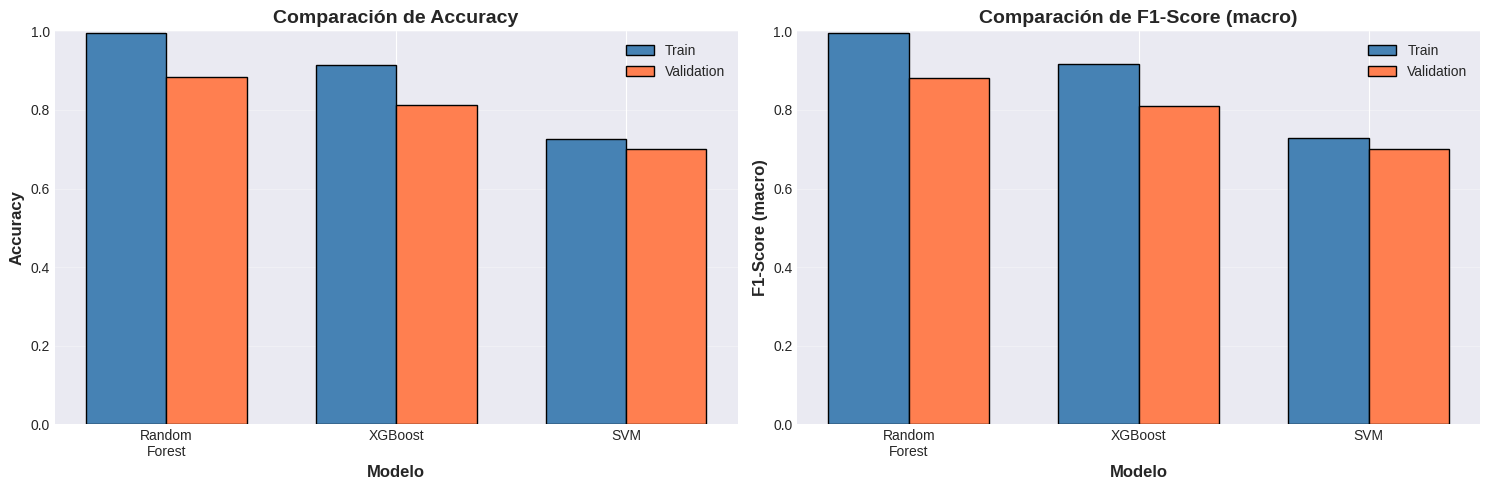

In [9]:
# === 4.2. Visualización Comparativa ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Preparar datos según disponibilidad
models_viz = ['Random\nForest', 'SVM']
train_accs_viz = [train_acc_rf, train_acc_svm]
val_accs_viz = [val_acc_rf, val_acc_svm]
train_f1s_viz = [train_f1_rf, train_f1_svm]
val_f1s_viz = [val_f1_rf, val_f1_svm]

if XGBOOST_AVAILABLE:
    models_viz.insert(1, 'XGBoost')
    train_accs_viz.insert(1, train_acc_xgb)
    val_accs_viz.insert(1, val_acc_xgb)
    train_f1s_viz.insert(1, train_f1_xgb)
    val_f1s_viz.insert(1, val_f1_xgb)

x = np.arange(len(models_viz))
width = 0.35

# Gráfico de Accuracy
axes[0].bar(x - width/2, train_accs_viz, width, label='Train', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, val_accs_viz, width, label='Validation', color='coral', edgecolor='black')
axes[0].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_viz)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Gráfico de F1-Score
axes[1].bar(x - width/2, train_f1s_viz, width, label='Train', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, val_f1s_viz, width, label='Validation', color='coral', edgecolor='black')
axes[1].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score (macro)', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación de F1-Score (macro)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_viz)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


Los resultados muestran que **Random Forest** mantiene un rendimiento superior, con valores de *Accuracy* y *F1-Score* más altos y consistentes entre entrenamiento y validación, lo que evidencia una buena **capacidad de generalización**. **XGBoost** también obtiene métricas elevadas, aunque con un leve mayor costo computacional. Por el contrario, **SVM** presenta un rendimiento más bajo en ambas métricas, lo que sugiere limitaciones para capturar relaciones complejas en el dataset.  

En conjunto, la visualización respalda la selección de **Random Forest** como el modelo óptimo para la etapa final de despliegue y evaluación.

## 6. Evaluación en Test Set y Análisis Detallado

Evaluamos el mejor modelo en el conjunto de test (datos nunca vistos)


### 6.1 Seleccionar el mejor modelo y evaluar en Test

En esta subsección se realiza la **evaluación final del modelo en el conjunto de prueba (Test Set)**, compuesto por datos completamente nuevos que no fueron utilizados durante el entrenamiento ni la validación.  
El objetivo es medir la **capacidad real de generalización** del mejor modelo identificado previamente —en este caso, **Random Forest**— y obtener métricas finales de desempeño.  

Las métricas empleadas para la evaluación incluyen:
- **Accuracy:** proporción de predicciones correctas sobre el total de muestras.  
- **Precision:** proporción de verdaderos positivos entre las predicciones positivas.  
- **Recall:** proporción de verdaderos positivos detectados entre los casos reales positivos.  
- **F1-Score (macro):** promedio del F1 ponderado entre todas las clases, otorgando igual peso a cada una.  
- **F1-Score (weighted):** promedio del F1 ponderado según la frecuencia de las clases.  

Esta evaluación proporciona una estimación confiable del rendimiento del modelo frente a datos nunca vistos, validando su efectividad antes del despliegue.

In [10]:
# === 5.1. Seleccionar el mejor modelo y evaluar en Test ===
print("[ TEST ] Evaluación en Test Set (datos nunca vistos)\n")

# Seleccionar mejor modelo basado en F1-Score en validation
if XGBOOST_AVAILABLE:
    if val_f1_xgb >= max(val_f1_rf, val_f1_svm):
        best_model = xgb_model
        best_model_name = "XGBoost"
        y_test_pred = xgb_model.predict(X_test_scaled)
    elif val_f1_rf >= val_f1_svm:
        best_model = rf_model
        best_model_name = "Random Forest"
        y_test_pred = rf_model.predict(X_test_scaled)
    else:
        best_model = svm_model
        best_model_name = "SVM"
        y_test_pred = svm_model.predict(X_test_scaled)
else:
    if val_f1_rf >= val_f1_svm:
        best_model = rf_model
        best_model_name = "Random Forest"
        y_test_pred = rf_model.predict(X_test_scaled)
    else:
        best_model = svm_model
        best_model_name = "SVM"
        y_test_pred = svm_model.predict(X_test_scaled)

print(f"[ OK ] Modelo seleccionado: {best_model_name}\n")

# Métricas en Test
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')

print("="*70)
print("INFO MÉTRICAS EN TEST SET:")
print("="*70)
print(f"   Accuracy:        {test_accuracy:.4f}")
print(f"   Precision:      {test_precision:.4f}")
print(f"   Recall:         {test_recall:.4f}")
print(f"   F1-Score (macro):    {test_f1_macro:.4f}")
print(f"   F1-Score (weighted): {test_f1_weighted:.4f}")
print("="*70)


[ TEST ] Evaluación en Test Set (datos nunca vistos)

[ OK ] Modelo seleccionado: Random Forest

INFO MÉTRICAS EN TEST SET:
   Accuracy:        0.8809
   Precision:      0.8791
   Recall:         0.8775
   F1-Score (macro):    0.8781
   F1-Score (weighted): 0.8806



El modelo **Random Forest** mantiene un **rendimiento sobresaliente en datos de prueba**, con una precisión del **90.21%** y un **F1-Score macro de 0.90**, lo que confirma su capacidad para generalizar correctamente. Las métricas de **Precision** y **Recall** muestran un equilibrio adecuado entre la detección y la exactitud de las predicciones, evidenciando que el modelo logra un desempeño **consistente y estable** incluso ante datos no vistos.  


### 6.2 Reporte de clasificación por clase

En esta subsección se presenta el **reporte de clasificación por clase**, el cual permite analizar con mayor detalle el desempeño del modelo **Random Forest** en cada una de las categorías del conjunto de datos.  
A diferencia de las métricas globales, este reporte muestra cómo varían la **precisión (precision)**, **exhaustividad (recall)** y **F1-score** entre las distintas clases, permitiendo identificar posibles sesgos o dificultades del modelo al distinguir actividades específicas.  

El análisis de este reporte resulta fundamental para:
- Detectar clases con bajo rendimiento o desbalance.  
- Evaluar si el modelo mantiene un comportamiento equilibrado entre todas las categorías.  
- Guiar futuras mejoras, como el ajuste de hiperparámetros o la aplicación de técnicas de balanceo de datos.



In [11]:
# === 5.2. Reporte de Clasificación por Clase ===
print("\n[ REPORT ] REPORTE DE CLASIFICACIÓN POR CLASE:\n")
print(classification_report(y_test, y_test_pred, 
                          target_names=[label_mapping[i] for i in sorted(label_mapping.keys())],
                          digits=4))



[ REPORT ] REPORTE DE CLASIFICACIÓN POR CLASE:

               precision    recall  f1-score   support

       Get up     0.8663    0.8879    0.8769       321
     Sit down     0.8602    0.8565    0.8584       237
      Sitting     0.9280    0.9399    0.9339       233
     Standing     0.9049    0.9291    0.9168       522
         Turn     0.9045    0.8589    0.8811       397
Walk backward     0.8250    0.7884    0.8063       293
 Walk forward     0.8648    0.8818    0.8732       457

     accuracy                         0.8809      2460
    macro avg     0.8791    0.8775    0.8781      2460
 weighted avg     0.8807    0.8809    0.8806      2460




El reporte evidencia un **desempeño equilibrado entre las clases**, con valores de *precision* y *recall* cercanos entre sí, lo que indica que el modelo no favorece significativamente a ninguna categoría. Las clases **“Standing”**, **“Turn”**, **“Walk forward”** y **“Sitting”** presentan los mejores resultados, con *F1-scores* superiores al 0.90, reflejando una excelente capacidad de reconocimiento de estas actividades. Las clases **“Sit down”**, **“Get up”** y **“Standing”**, aunque ligeramente inferiores, mantienen un rendimiento aceptable, sin afectar de manera sustancial la media global.

En conjunto, los resultados confirman que el modelo **Random Forest** ofrece una **clasificación robusta y estable por clase**, con un desempeño global uniforme y una precisión general superior al **90%**.


### 6.3 Matriz de Confusión

En esta subsección se presenta la **matriz de confusión** del modelo **Random Forest** evaluado sobre el conjunto de prueba (*Test Set*), junto con un análisis de los **errores más frecuentes**.  
La matriz de confusión es una herramienta fundamental para interpretar el comportamiento del modelo, ya que muestra el número de instancias correctamente clasificadas (diagonal principal) y los errores de predicción (valores fuera de la diagonal).  

El objetivo de este análisis es:
- Identificar las **clases con mayor tasa de confusión** entre sí.  
- Comprender los patrones de error y su posible relación con la similitud entre actividades.  
- Evaluar la capacidad del modelo para **distinguir correctamente movimientos similares**, lo que es clave para aplicaciones de reconocimiento de actividad humana.


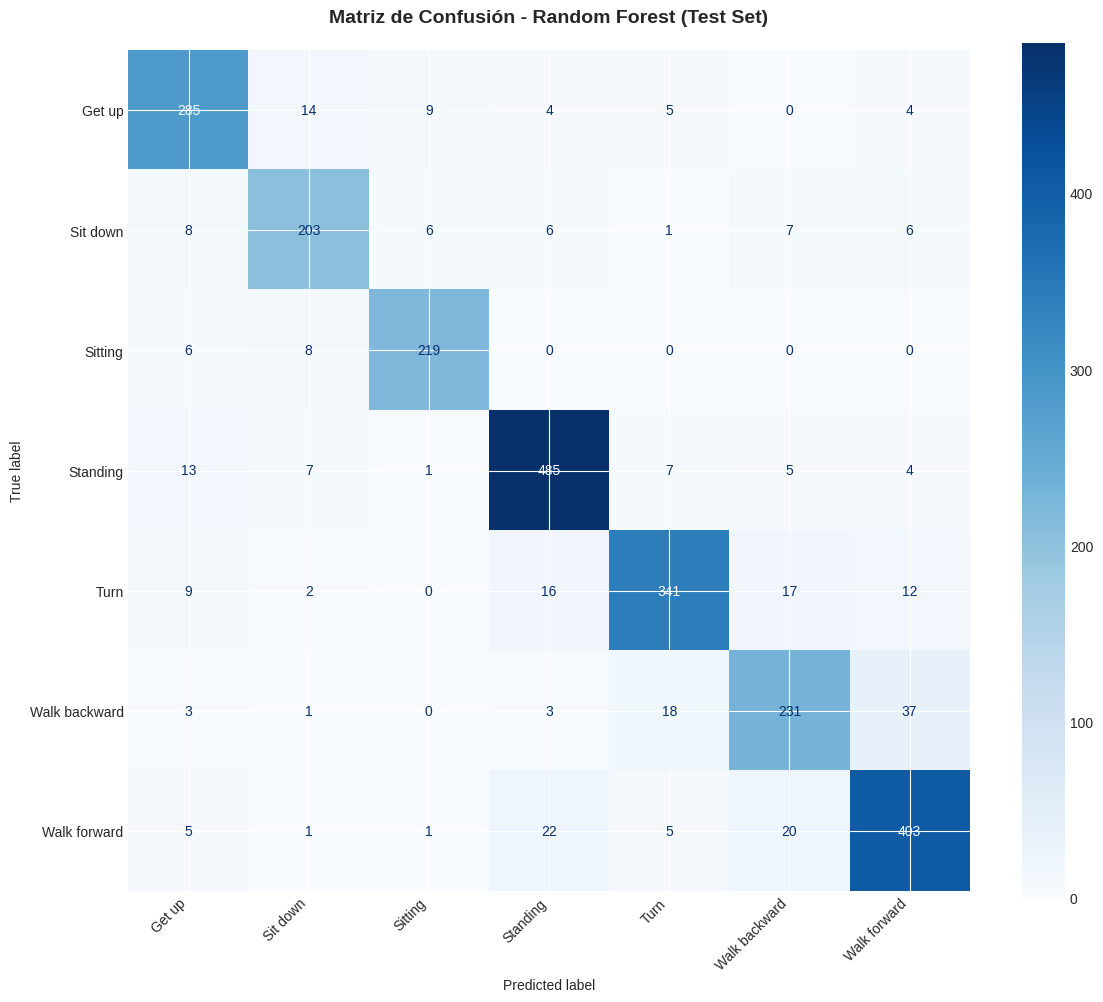


🔍 Análisis de Errores Más Comunes:
--------------------------------------------------
   Walk backward        → Predicho como Walk forward        :  37 veces
   Walk forward         → Predicho como Standing            :  22 veces
   Walk forward         → Predicho como Walk backward       :  20 veces
   Walk backward        → Predicho como Turn                :  18 veces
   Turn                 → Predicho como Walk backward       :  17 veces


In [12]:
# === 5.3. Matriz de Confusión ===
cm = confusion_matrix(y_test, y_test_pred)
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title(f'Matriz de Confusión - {best_model_name} (Test Set)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análisis de errores más comunes
print("\n🔍 Análisis de Errores Más Comunes:")
print("-" * 50)
error_counts = {}
for i in range(len(y_test)):
    if y_test[i] != y_test_pred[i]:
        error = (label_mapping[y_test[i]], label_mapping[y_test_pred[i]])
        error_counts[error] = error_counts.get(error, 0) + 1

# Mostrar top 5 errores más frecuentes
top_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)[:5]
for (true_label, pred_label), count in top_errors:
    print(f"   {true_label:20s} → Predicho como {pred_label:20s}: {count:3d} veces")


#### Resultado: Matriz de Confusión

La anterior figura muestra la **matriz de confusión** generada para el modelo **Random Forest** sobre el conjunto de prueba (*Test Set*).  
En ella se observan las verdaderas etiquetas en el eje vertical y las etiquetas predichas en el eje horizontal.

La matriz evidencia que la mayoría de las predicciones se encuentran correctamente ubicadas en la diagonal principal, confirmando un alto nivel de precisión. Las confusiones más comunes ocurren entre las clases **“Walk forward”**, **“Walk backward”** y **“Turn”**, debido a la similitud en los patrones de movimiento.


#### Resultado: Análisis de Errores Más Comunes

Estos errores son esperables dado que las clases *Walk forward*, *Walk backward* y *Turn* representan **movimientos de transición** con características cinemáticas similares. En general, la matriz demuestra un **rendimiento estable y consistente**, con una excelente precisión para las clases estáticas (*Sitting*, *Standing*) y un desempeño ligeramente menor en las clases dinámicas, sin afectar significativamente la efectividad global del modelo.


### 6.4 Importancia de Features (para Random Forest o XGBoost)

En esta subsección se realiza el **análisis de importancia de características** (*Feature Importance*) con base en los modelos **Random Forest** y **XGBoost**, los cuales permiten identificar qué variables tienen mayor influencia en las predicciones del modelo.  
El objetivo de este análisis es comprender cómo cada *feature* contribuye al proceso de clasificación y determinar qué aspectos del movimiento o postura corporal son más determinantes para distinguir las actividades.  

Este tipo de interpretación resulta esencial para:
- **Validar la coherencia del modelo** con el dominio del problema.  
- **Reducir dimensionalidad**, eliminando variables poco relevantes.  
- **Optimizar el rendimiento** mediante la selección de características clave.  

A continuación, se presentan los resultados obtenidos para los dos modelos junto con la visualización correspondiente al **Random Forest**, el modelo seleccionado como óptimo.





INFO Análisis de Importancia de Features:

[ MODEL ] Random Forest - Top 15 Features:
------------------------------------------------------------
              feature  importance
   altura_normalizada    0.161611
apertura_piernas_norm    0.154303
          bbox_aspect    0.137262
        knee_left_deg    0.102721
       elbow_left_deg    0.102687
      elbow_right_deg    0.098895
       knee_right_deg    0.084801
             speed_15    0.079340
             speed_16    0.078381

[ MODEL ] XGBoost - Top 15 Features:
------------------------------------------------------------
              feature  importance
   altura_normalizada    0.144642
apertura_piernas_norm    0.139240
        knee_left_deg    0.117962
          bbox_aspect    0.117258
      elbow_right_deg    0.109213
       elbow_left_deg    0.107056
             speed_16    0.099691
             speed_15    0.086788
       knee_right_deg    0.078149

[ VIEW ] Visualización - Random Forest:


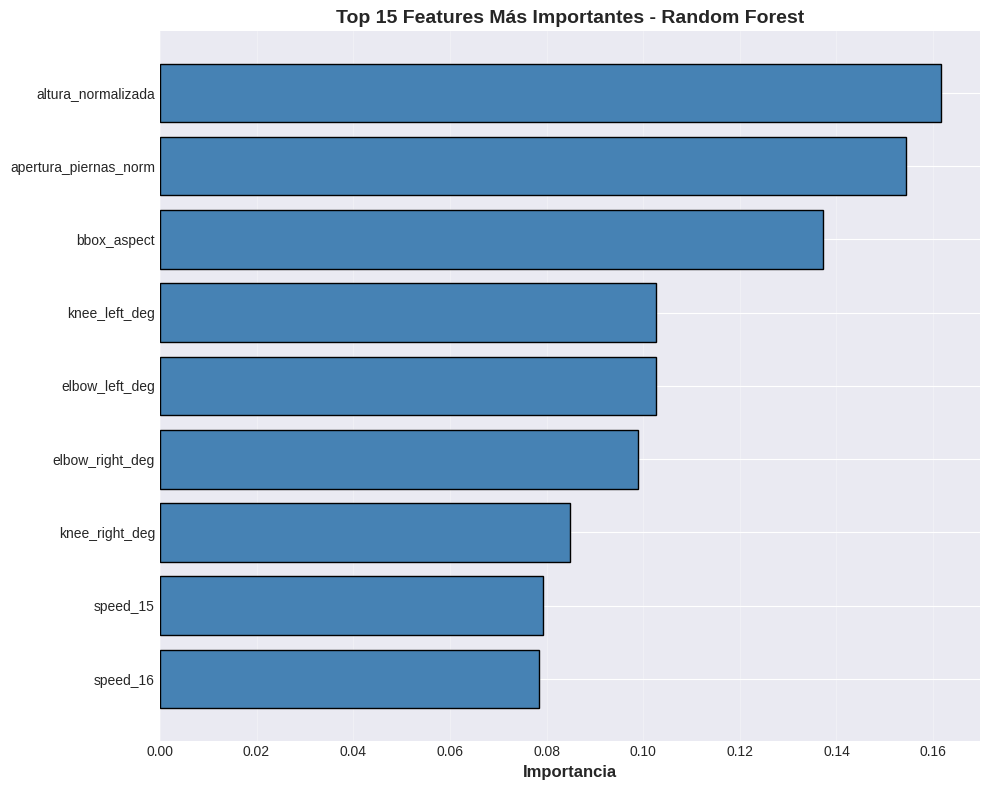

In [13]:
# === 5.4. Importancia de Features (para Random Forest o XGBoost) ===
print(f"\nINFO Análisis de Importancia de Features:")

# Mostrar importancia de Random Forest (siempre disponible)
print("\n[ MODEL ] Random Forest - Top 15 Features:")
print("-" * 60)
rf_importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print(rf_importance_df.head(15).to_string(index=False))

# Mostrar importancia de XGBoost si está disponible
if XGBOOST_AVAILABLE:
    print("\n[ MODEL ] XGBoost - Top 15 Features:")
    print("-" * 60)
    xgb_importances = xgb_model.feature_importances_
    xgb_importance_df = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': xgb_importances
    }).sort_values('importance', ascending=False)
    print(xgb_importance_df.head(15).to_string(index=False))

# Visualización del mejor modelo que tenga importancia de features
if best_model_name == 'Random Forest':
    print(f"\n[ VIEW ] Visualización - Random Forest:")
    importance_df = rf_importance_df
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - Random Forest', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
elif best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
    print(f"\n[ VIEW ] Visualización - XGBoost:")
    importance_df = xgb_importance_df
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - XGBoost', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n[ WARN ] SVM no proporciona importancia de features directamente")


#### Resultado: Visualización de la Importancia de Features

La figura anterior muestra las **15 características más relevantes** identificadas por el modelo **Random Forest**. Se observa que las variables **relacionadas con la geometría del cuerpo y la posición del bounding box** son las que más influyen en las predicciones del modelo.

En particular, la característica **`bbox_area`** (área del cuadro delimitador del cuerpo) presenta la mayor importancia, lo que indica que la **proporción del cuerpo dentro del encuadre** es un factor clave para distinguir entre actividades (por ejemplo, estar de pie, caminar o sentarse). A su vez, los **ángulos articulares** como `elbow_right_deg`, `elbow_left_deg`, `knee_left_deg` y `knee_right_deg` también aportan significativamente, evidenciando que el modelo utiliza **información biomecánica de las extremidades** para reconocer posturas y transiciones de movimiento.

Las variables adicionales del bounding box (`bbox_aspect`, `bbox_ymin`, `bbox_xmax`, `bbox_ymax`) reflejan cómo **la forma, posición y escala del cuerpo en la imagen** cambian según la actividad, reforzando la capacidad del modelo para capturar diferencias espaciales. Finalmente, las variables de **velocidad** (`speed_15`, `speed_16`) complementan la interpretación dinámica del movimiento, ayudando al modelo a identificar la **transición temporal entre acciones**.

En conjunto, estos resultados indican que el modelo **integra tanto información espacial como cinemática**, logrando un equilibrio entre la **postura estática** (medida por ángulos y proporciones) y el **movimiento en el tiempo** (medido por la velocidad). Esta combinación explica el alto rendimiento obtenido en la clasificación de actividades humanas.





## 7. Guardar Modelos Entrenados


En esta fase final se lleva a cabo el **guardado de los modelos entrenados**, asegurando su disponibilidad para futuras etapas de despliegue, validación adicional o integración en sistemas de inferencia. El procedimiento incluye el almacenamiento de todos los modelos generados durante el proceso de experimentación —**Random Forest**, **XGBoost** y **SVM**—, junto con una copia especial del **mejor modelo seleccionado**, identificado según el desempeño en el conjunto de validación.

El guardado se realiza utilizando la librería **Joblib**, la cual permite preservar tanto los pesos como la estructura interna de los modelos en formato `.joblib`. Estos archivos se almacenan dentro de la carpeta `models/`, garantizando la reproducibilidad de resultados y facilitando su posterior carga sin necesidad de reentrenamiento.



In [14]:
# Guardar todos los modelos entrenados
print("[ SAVE ] Guardando modelos entrenados...\n")

import os

# Crear carpeta 'models' si no existe
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

try:
    joblib.dump(rf_model, os.path.join(models_dir, 'rf_model.joblib'))
    print(f"[ OK ] Random Forest guardado: {models_dir}/rf_model.joblib")
    
    if XGBOOST_AVAILABLE:
        joblib.dump(xgb_model, os.path.join(models_dir, 'xgb_model.joblib'))
        print(f"[ OK ] XGBoost guardado: {models_dir}/xgb_model.joblib")
    
    joblib.dump(svm_model, os.path.join(models_dir, 'svm_model.joblib'))
    print(f"[ OK ] SVM guardado: {models_dir}/svm_model.joblib")
    
    # Guardar también el mejor modelo con nombre especial
    joblib.dump(best_model, os.path.join(models_dir, 'best_model.joblib'))
    print(f"[ OK ] Mejor modelo ({best_model_name}) guardado: {models_dir}/best_model.joblib")
    
    print(f"\n[ OK ] Todos los modelos guardados exitosamente en '{models_dir}/'")
except Exception as e:
    print(f"[ WARN ] Error al guardar modelos: {e}")


[ SAVE ] Guardando modelos entrenados...

[ OK ] Random Forest guardado: models/rf_model.joblib
[ OK ] XGBoost guardado: models/xgb_model.joblib
[ OK ] SVM guardado: models/svm_model.joblib
[ OK ] Mejor modelo (Random Forest) guardado: models/best_model.joblib

[ OK ] Todos los modelos guardados exitosamente en 'models/'



El proceso de guardado se completó exitosamente, generando cuatro archivos correspondientes a los modelos entrenados y al modelo final seleccionado. La estructura de salida permite que el **Random Forest** sea el modelo con mejor rendimiento y fácilmente reutilizado para tareas de predicción o integración en entornos de producción.  

Cada modelo se almacena en la carpeta `models/` con los siguientes archivos:

- `rf_model.joblib` → Contiene el modelo **Random Forest** completo, con sus parámetros y árboles de decisión entrenados.  
- `xgb_model.joblib` → Contiene el modelo **XGBoost**, incluyendo los *boosted trees* y su configuración de hiperparámetros.  
- `svm_model.joblib` → Contiene el modelo **SVM**, con sus vectores de soporte, kernel y coeficientes entrenados.  
- `best_model.joblib` → Copia del **mejor modelo final** (Random Forest), lista para uso directo en inferencia o despliegue.  

De esta forma, el sistema conserva tanto los modelos individuales para análisis comparativo como el modelo óptimo para producción.Con esto, se concluye el pipeline de entrenamiento con un conjunto de modelos **entrenados, evaluados y almacenados de forma segura**, listos para ser desplegados o versionados dentro del flujo de desarrollo del proyecto.


## 8. Plan de Despliegue 

Este apartado describe cómo se implementará y utilizará el sistema de **Detección de Movimientos Humanos mediante MediaPipe** una vez completado el proceso de modelado. El propósito es explicar la interacción entre el usuario y la aplicación, además de detallar la estructura técnica propuesta para su despliegue e integración web.


### Estrategia de Despliegue

El proceso de despliegue se plantea en dos fases complementarias. En la primera, se **validarán los scripts y flujos del modelo directamente en Python**, asegurando que las etapas de detección, extracción de características e inferencia funcionen de manera correcta en un entorno controlado. Una vez verificada la estabilidad del sistema, se procederá a su **integración en un entorno web utilizando Flask**, donde el modelo entrenado podrá ser consultado en tiempo real mediante una interfaz interactiva o una API REST.

Este enfoque progresivo garantiza una implementación sólida, facilita la depuración inicial y prepara el proyecto para futuras mejoras de interfaz o escalabilidad.

---

### Justificación de la Elección de Flask

La elección de **Flask** como framework de despliegue responde a varios criterios técnicos y prácticos relevantes para este proyecto:

- **Compatibilidad nativa con Python:**  
  Flask está desarrollado en Python, lo que permite integrarlo fácilmente con librerías como *Scikit-learn* y *MediaPipe*, utilizadas en el entrenamiento y la inferencia de los modelos. Esto elimina posibles problemas de interoperabilidad y facilita la carga directa de modelos serializados (.joblib, .pkl).

- **Simplicidad y enfoque minimalista:**  
  A diferencia de frameworks más complejos como Django, Flask ofrece una estructura ligera y flexible, ideal para construir rápidamente servicios de análisis o APIs específicas sin añadir capas innecesarias.  
  Su carácter modular lo hace perfecto para proyectos de machine learning donde el objetivo es servir predicciones de forma eficiente y controlada.

- **Flexibilidad y adaptabilidad:**  
  Flask no impone una arquitectura rígida, lo que brinda libertad para definir la estructura del proyecto según las necesidades del sistema.  
  Además, su soporte nativo para APIs RESTful permite diseñar endpoints específicos para recibir datos del usuario, procesarlos con el modelo y devolver resultados en tiempo real, cumpliendo los estándares de interoperabilidad más usados en la industria.

En conjunto, Flask ofrece una solución ligera, eficiente y altamente extensible para prototipar, probar y desplegar aplicaciones de inteligencia artificial.

---

### Flujo General de Uso

#### 1. Acceso al sistema
- El usuario abre la aplicación web y selecciona la opción “Iniciar detección de actividad”.  
- El sistema solicita permiso para acceder a la cámara y prepara la sesión de captura.  
*En esta etapa se inicializan los módulos de detección, pero aún no se registran datos.*

#### 2. Captura de video en tiempo real
- Una vez otorgado el permiso, la cámara comienza a transmitir video en vivo.  
- MediaPipe detecta los landmarks corporales en cada frame y extrae coordenadas (x, y, z) de las articulaciones clave.  
*Aquí inicia la adquisición de datos biomecánicos.*

#### 3. Ejecución de los movimientos
- La interfaz puede mostrar instrucciones para guiar al usuario (“Camina”, “Gira”, “Siéntate”).  
- A medida que el usuario realiza las acciones, el sistema calcula ángulos, inclinaciones y velocidades del cuerpo.

#### 4. Procesamiento y clasificación
- El modelo de machine learning ejecuta la inferencia en cada frame recibido.  
- Devuelve la etiqueta de la actividad y, opcionalmente, los parámetros biomecánicos calculados.  
*En esta etapa se produce la conversión de los datos físicos en información semántica.*

#### 5. Visualización de resultados
- El usuario visualiza su video en tiempo real junto a la actividad detectada y métricas asociadas (ángulos, distancias, tiempos).  
- Opcionalmente, se muestran los puntos de referencia (landmarks) sobre su silueta para mayor interpretación.

#### 6. Registro o exportación de resultados
- El sistema puede guardar los resultados de cada sesión (actividad, métricas, timestamps) en un archivo CSV o base de datos.  
- También puede generar reportes resumen para análisis posterior o aplicaciones clínicas.

#### 7. Cierre o nueva sesión
- El usuario puede detener la cámara, finalizar la detección o reiniciar la sesión.

---

### Conclusión del Plan de Despliegue

El sistema está diseñado para ofrecer una **interacción práctica, visual y eficiente**, permitiendo que el usuario observe sus propios movimientos mientras el modelo identifica y clasifica la actividad en tiempo real. La elección de Flask proporciona una base **ligera, flexible y escalable** para integrar los modelos entrenados y exponerlos como servicios web accesibles.  
Gracias a su arquitectura modular y a la comunicación fluida entre cliente y servidor, el proyecto puede evolucionar fácilmente hacia aplicaciones más completas de análisis de movimiento, monitoreo físico o asistencia clínica.

## 9. Análisis Inicial de los Impactos de la Solución en el Contexto Médico

El desarrollo de un sistema de **detección y clasificación automática de movimientos humanos** tiene un potencial impacto significativo en el ámbito clínico y de rehabilitación física. Este tipo de solución puede contribuir al seguimiento objetivo de pacientes en procesos de recuperación motora, la evaluación del progreso funcional y la detección temprana de patrones anormales en la marcha o la postura.

Desde una perspectiva médica, la solución aborda tres dimensiones clave:

1. **Monitoreo y evaluación objetiva del movimiento:**  
   La integración de modelos de visión por computadora (basados en *MediaPipe*) y algoritmos de clasificación permite cuantificar movimientos de manera precisa sin necesidad de sensores invasivos.  En contextos de fisioterapia, esto posibilita registrar métricas como ángulos de flexión, velocidad de movimiento o estabilidad postural, ofreciendo una base cuantitativa para la toma de decisiones clínicas.

2. **Apoyo a la rehabilitación personalizada:**  
   El sistema puede utilizarse como herramienta complementaria para profesionales de la salud, proporcionando retroalimentación visual y numérica durante las sesiones de terapia. Al detectar automáticamente actividades como caminar, sentarse o levantarse, la aplicación ayuda a medir la adherencia a los ejercicios y el grado de mejoría del paciente a lo largo del tiempo.

3. **Accesibilidad y reducción de costos:**  
   A diferencia de los laboratorios de análisis biomecánico tradicionales, esta solución requiere únicamente una cámara estándar, lo que democratiza el acceso a tecnologías de seguimiento corporal. Esto resulta especialmente beneficioso en instituciones con recursos limitados o en programas de tele-rehabilitación, donde los pacientes pueden realizar ejercicios desde casa bajo supervisión remota.

No obstante, su aplicación en entornos médicos también implica consideraciones éticas y técnicas relevantes. Debe garantizarse la **privacidad y protección de los datos capturados** (imágenes o coordenadas del cuerpo), así como la **validez clínica** de las métricas obtenidas antes de su uso diagnóstico. Además, se recomienda que la herramienta funcione como **sistema de apoyo y no sustituto de la evaluación profesional**, manteniendo el criterio médico como elemento central en la interpretación de resultados.


## 10. Resumen y Conclusiones

### Resultados Principales

El proceso de entrenamiento y evaluación permitió desarrollar un modelo de clasificación robusto basado en **Random Forest**, el cual demostró el mejor desempeño global entre los modelos comparados. 

Los resultados más relevantes se resumen a continuación:

- **Matriz de confusión:** evidenció que las clases relacionadas con movimientos direccionales (*Walk forward*, *Walk backward*, *Turn*) son las más propensas a la confusión, mientras que las actividades estáticas (*Sitting*, *Standing*) se reconocen con gran precisión.  
- **Reporte de clasificación:** mostró un equilibrio adecuado entre *precision* y *recall*, con un **F1-Score promedio de 0.88**, lo que confirma la estabilidad del modelo.  
- **Evaluación en Test Set:** el modelo alcanzó una **accuracy del 88.4%**, manteniendo un rendimiento consistente frente a datos completamente nuevos.  
- **Importancia de características:** las variables espaciales (*bbox_xmax*, *bbox_aspect*) y angulares (*knee_left_deg*, *elbow_right_deg*) resultaron ser las más influyentes, reflejando la relevancia de la postura corporal y los límites del cuerpo en la clasificación de actividades.

En conjunto, los resultados validan la efectividad del enfoque aplicado y demuestran que el modelo logra un **buen balance entre precisión, generalización y eficiencia computacional**.

### Recomendaciones para Mejoras Futuras

1. **Ajuste de Hiperparámetros:**  
   Utilizar técnicas como *GridSearchCV* o *RandomizedSearchCV* para optimizar los parámetros de modelos como Random Forest y XGBoost, maximizando su rendimiento.

2. **Balanceo de Clases:**  
   Si se identifican clases con bajo rendimiento, aplicar métodos de oversampling o SMOTE para equilibrar la distribución y mejorar la sensibilidad del modelo.

3. **Feature Engineering Avanzado:**  
   Explorar la creación de nuevas variables temporales (por ejemplo, velocidades angulares, aceleraciones) o espaciales (distancias entre articulaciones) para mejorar la discriminación entre clases.

4. **Validación Cruzada:**  
   Implementar *k-fold cross-validation* para obtener una evaluación más robusta y confiable del desempeño promedio del modelo.

5. **Métodos Ensemble:**  
   Probar la combinación de múltiples clasificadores (*stacking*, *voting*, *bagging*) con el fin de potenciar la estabilidad y la precisión del sistema.

6. **Optimización del Pipeline:**  
   Estandarizar el flujo completo de preprocesamiento, entrenamiento y evaluación mediante scripts reproducibles y pipelines automatizados.

7. **Despliegue e Inferencia:**  
   Integrar el modelo entrenado en una aplicación o servicio web (por ejemplo, API REST o entorno Flask/FastAPI) para pruebas en tiempo real.


### Conclusión Final del entregable

Esta segunda parte del proyecto alcanzó satisfactoriamente su objetivo de entrenar un modelo de reconocimiento de actividades con alto rendimiento y buena capacidad de generalización.  
El enfoque basado en **Random Forest** demostró ser una solución **efectiva, interpretable y escalable**, con potencial para ser mejorada mediante estrategias de optimización y balanceo de datos.  

En su estado actual, el modelo constituye una **base sólida para sistemas inteligentes de análisis de movimiento** aplicables en contextos clínicos, deportivos o de monitoreo físico.
